In [ ]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset

/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset


In [ ]:
! pwd
! ls

/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset
tesse_depth_cam_mono_image_raw	tesse_right_cam_mono_image_raw
tesse_left_cam_mono_image_raw	tesse_right_cam_rgb_image_raw
tesse_left_cam_rgb_image_raw	tesse_seg_cam_rgb_image_raw


In [ ]:
%cd /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_right_cam_rgb_image_raw

/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_right_cam_rgb_image_raw


# Extract tesse_seg_cam_converted_image_raw

In [ ]:
import os
import numpy as np
import shutil
import cv2
import csv
from google.colab.patches import cv2_imshow
import torch
import torch.nn.functional as F
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.rosbag1 import Writer
from rosbags.image import message_to_cvimage
from rosbags.typesys import Stores, get_typestore

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

drive_path = '/content/drive/MyDrive/SBU/Advanced_Project_Robotics/'

bag_path = drive_path+'uHumans2_office_s1_00h_v2.bag'

updates_bagpath = drive_path+'updated_uHumans2.bag'

results_dir = drive_path+'dataset'

topic_name = 'tesse_right_cam_rgb_image_raw'

# bagpath = Path('/content/drive/MyDrive/SBU/Advanced_Project_Robotics/bag_pcd_topics.bag')
bagpath = Path(bag_path)

In [ ]:
# completed_topics = ['tesse_seg_cam_rgb_image_raw', 'tesse_right_cam_mono_image_raw', 'tesse_right_cam_rgb_image_raw', 'tesse_left_cam_mono_image_raw', 'tesse_left_cam_rgb_image_raw']
def extract_to_folders(bag_path, base_output_dir):
    bag_path = Path(bag_path)
    with AnyReader([bag_path]) as reader:
        for connection in reader.connections:
            topic_name = connection.topic.replace('/', '_').lstrip('_')
            if topic_name != 'tesse_seg_cam_converted_image_raw':
              continue
            else:
            # if topic_name in completed_topics:
            #     continue
              print(f"Processing topic: {topic_name}")
              topic_dir = Path(base_output_dir) / topic_name
              topic_dir.mkdir(parents=True, exist_ok=True)

              # CSV to store metadata for reconstruction
              csv_path = topic_dir / "metadata.csv"
              with open(csv_path, 'w', newline='') as csvfile:
                  writer = csv.writer(csvfile)
                  writer.writerow(['filename', 'sec', 'nanosec', 'frame_id', 'encoding'])

                  for conn, timestamp, rawdata in reader.messages(connections=[connection]):
                      msg = reader.deserialize(rawdata, conn.msgtype)
                      # Handle Depth Images (32FC1)
                      if msg.encoding == '32FC1':
                          # Get raw numpy array from message data
                          # 32FC1 means 4 bytes per pixel (float32)
                          depth_img = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width)

                          # Normalize to 0-255 range for saving as JPG
                          # Note: You may need to adjust the 'alpha' based on your scene distance
                          depth_norm = cv2.normalize(depth_img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
                          cv_img = depth_norm
                      else:
                          # Standard color image conversion
                          cv_img = message_to_cvimage(msg, 'mono8')

                      # Use timestamp for unique filename
                      fname = f"{timestamp}.jpg"
                      cv2.imwrite(str(topic_dir / fname), cv_img)

                      # Save ROS header details
                      writer.writerow([fname, msg.header.stamp.sec,
                                        msg.header.stamp.nanosec,
                                        msg.header.frame_id, msg.encoding])
    print(f"Extraction complete to {base_output_dir}")

extract_to_folders(bag_path, results_dir)


Processing topic: tesse_seg_cam_converted_image_raw
Extraction complete to /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset


In [ ]:
bag_path = drive_path+'uHumans2_office_s1_00h_v2.bag'
bag_path = Path(bag_path)
with AnyReader([bag_path]) as reader:
    res = reader.connections
    print(res)

[Connection(id=0, topic='/tf', msgtype='tf2_msgs/msg/TFMessage', msgdef=MessageDefinition(format=<MessageDefinitionFormat.MSG: 1>, data='geometry_msgs/TransformStamped[] transforms\n\n================================================================================\nMSG: geometry_msgs/TransformStamped\n# This expresses a transform from coordinate frame header.frame_id\n# to the coordinate frame child_frame_id\n#\n# This message is mostly used by the \n# <a href="http://wiki.ros.org/tf">tf</a> package. \n# See its documentation for more information.\n\nHeader header\nstring child_frame_id # the frame id of the child frame\nTransform transform\n\n================================================================================\nMSG: std_msgs/Header\n# Standard metadata for higher-level stamped data types.\n# This is generally used to communicate timestamped data \n# in a particular coordinate frame.\n# \n# sequence ID: consecutively increasing ID \nuint32 seq\n#Two-integer timestamp that i

In [ ]:
for i in res:
  print(i)

Connection(id=0, topic='/tf', msgtype='tf2_msgs/msg/TFMessage', msgdef=MessageDefinition(format=<MessageDefinitionFormat.MSG: 1>, data='geometry_msgs/TransformStamped[] transforms\n\n================================================================================\nMSG: geometry_msgs/TransformStamped\n# This expresses a transform from coordinate frame header.frame_id\n# to the coordinate frame child_frame_id\n#\n# This message is mostly used by the \n# <a href="http://wiki.ros.org/tf">tf</a> package. \n# See its documentation for more information.\n\nHeader header\nstring child_frame_id # the frame id of the child frame\nTransform transform\n\n================================================================================\nMSG: std_msgs/Header\n# Standard metadata for higher-level stamped data types.\n# This is generally used to communicate timestamped data \n# in a particular coordinate frame.\n# \n# sequence ID: consecutively increasing ID \nuint32 seq\n#Two-integer timestamp that is

# Mask2Former

In [ ]:
# Install dependencies
!pip install transformers torch torchvision Pillow numpy
# Mask2FormerImageProcessor
from transformers import Mask2FormerImageProcessor, Mask2FormerForUniversalSegmentation
from PIL import Image
import numpy as np
import os
import torch
from pathlib import Path

# Load model — ADE20K semantic segmentation (150 classes, matches Hydra's labelspace)
extractor = Mask2FormerImageProcessor.from_pretrained(
    "facebook/mask2former-swin-large-ade-semantic"
)
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-large-ade-semantic"
)
model.eval()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/866M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

'\n# Run on the RGB camera (left cam is what Hydra uses)\nprocess_folder(\n    input_dir="/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_left_cam_rgb_image_raw",\n    output_dir="/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_seg_cam_semantic"\n)\n'

In [ ]:
def segment_image(image_path: Path) -> np.ndarray:
    """Returns a single-channel uint8 label map, same size as input image."""
    image = Image.open(image_path).convert("RGB")
    inputs = extractor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    # Post-process to semantic segmentation map
    seg = extractor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0]  # shape: (H, W), dtype: int64, values: 0–149
    return seg.numpy().astype(np.uint8)

# Process a whole folder
def process_folder(input_dir: str, output_dir: str):
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    image_files = sorted(input_path.glob("*.jpg")) + sorted(input_path.glob("*.png"))
    print(f"Found {len(image_files)} images in {input_dir}")

    for i, img_file in enumerate(image_files):
        label_map = segment_image(img_file)
        # Save as PNG (lossless, preserves integer label values)
        # Keep the SAME filename/timestamp as the source image
        out_file = output_path / (img_file.stem + ".png")
        Image.fromarray(label_map, mode="L").save(out_file)

        if i % 10 == 0:
            print(f"  [{i}/{len(image_files)}] {img_file.name}")

    print(f"Done → {output_path}")

# Run on the RGB camera (left cam is what Hydra uses)
process_folder(
    input_dir="/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_left_cam_rgb_image_raw",
    output_dir="/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/left_cam_rgb_semantics"
)


Found 8307 images in /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_left_cam_rgb_image_raw


/tmp/ipykernel_9055/1970815727.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(label_map, mode="L").save(out_file)


  [0/8307] 100004900000.jpg
  [10/8307] 100654899999.jpg
  [20/8307] 101254900000.jpg


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Quick sanity check — visualize one label map
label = np.array(Image.open("/content/drive/.../tesse_seg_cam_semantic/19804880000.png"))
print(f"Shape: {label.shape}, dtype: {label.dtype}")
print(f"Unique labels: {np.unique(label)}")  # Should be integers 0-149
print(f"Min: {label.min()}, Max: {label.max()}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(Image.open(".../tesse_left_cam_rgb_image_raw/19804880000.jpg"))
plt.title("RGB input")
plt.subplot(1,2,2)
plt.imshow(label, cmap="tab20")
plt.title("Semantic labels")
plt.colorbar()
plt.show()

# segformer

In [ ]:
# Option A2 — SegFormer, lighter and faster, still good accuracy
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch.nn.functional as F

extractor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b5-finetuned-ade-640-640"
)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b5-finetuned-ade-640-640"
)
model.eval()

def segment_image(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    inputs = extractor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    # Upsample logits back to original image size
    logits = F.interpolate(
        outputs.logits,
        size=image.size[::-1],   # (H, W)
        mode="bilinear",
        align_corners=False
    )
    seg = logits.argmax(dim=1).squeeze().numpy().astype(np.uint8)
    return seg

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/339M [00:00<?, ?B/s]

Original image: 


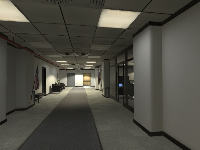

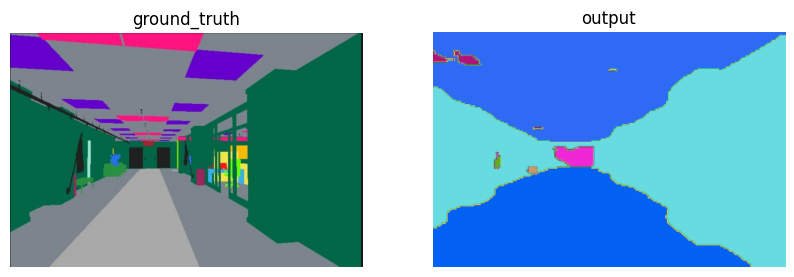

In [ ]:
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
res = segment_image("sample_rgb_image.png")

np.random.seed(42)
PALETTE = np.random.randint(0, 255, (256, 3), dtype=np.uint8)

def colorize_mask(mask):
  mask = cv2.resize(mask, (768, 512))
  return PALETTE[mask]

img = cv2.imread("sample_rgb_image.png")

print("Original image: ")
cv2_imshow(img)

# Load images
img1 = mpimg.imread('expected_ground_truth.png')

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img1)
ax[0].axis('off')  # Hide axes for a cleaner look
ax[0].set_title('ground_truth')

ax[1].imshow(colorize_mask(res))
ax[1].axis('off')
ax[1].set_title('output')

plt.show()

# OneFormer - Level1



In [ ]:

# Option A1 — OneFormer, generally more accurate than Mask2Former
!pip install transformers torch torchvision

from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import numpy as np
import torch
from pathlib import Path


processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
    size={"shortest_edge": 640, "longest_edge": 2560}  # default is 512/2048
)
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large"
)
model.eval()

def segment_image(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    # OneFormer needs a task input
    inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    seg = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0]
    return seg.numpy().astype(np.uint8)

Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

In [ ]:


!pip install pydensecrf2

import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_labels, create_pairwise_bilateral, create_pairwise_gaussian
import numpy as np
from PIL import Image

def apply_crf(rgb_image: np.ndarray, label_map: np.ndarray, n_classes=150,
              n_iters=10) -> np.ndarray:
    """
    rgb_image: (H, W, 3) uint8
    label_map: (H, W) uint8 with class IDs
    Returns refined (H, W) uint8 label map
    """
    H, W = label_map.shape
    d = dcrf.DenseCRF2D(W, H, n_classes)

    # Unary potential from label map (treat as confident predictions)
    unary = unary_from_labels(label_map, n_classes, gt_prob=0.7, zero_unsure=False)
    d.setUnaryEnergy(unary)

    # Pairwise Gaussian (smoothness): penalizes nearby pixels with different labels
    d.addPairwiseGaussian(sxy=3, compat=3)

    # Pairwise Bilateral (appearance): uses RGB to sharpen boundaries
    d.addPairwiseBilateral(
        sxy=80, srgb=13,
        rgbim=rgb_image,
        compat=10
    )

    Q = d.inference(n_iters)
    refined = np.argmax(Q, axis=0).reshape(H, W).astype(np.uint8)
    return refined

# Usage in your pipeline
def segment_image_with_crf(image_path, processor, model):
    image = Image.open(image_path).convert("RGB")
    rgb_array = np.array(image)

    inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    seg = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0].numpy().astype(np.uint8)

    refined = apply_crf(rgb_array, seg)
    return refined

In [ ]:
segmented_img_with_crf = segment_image_with_crf("sample_rgb_image.png", processor, model)

segmented_img = segment_image("sample_rgb_image.png")

Original image: 


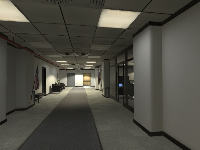

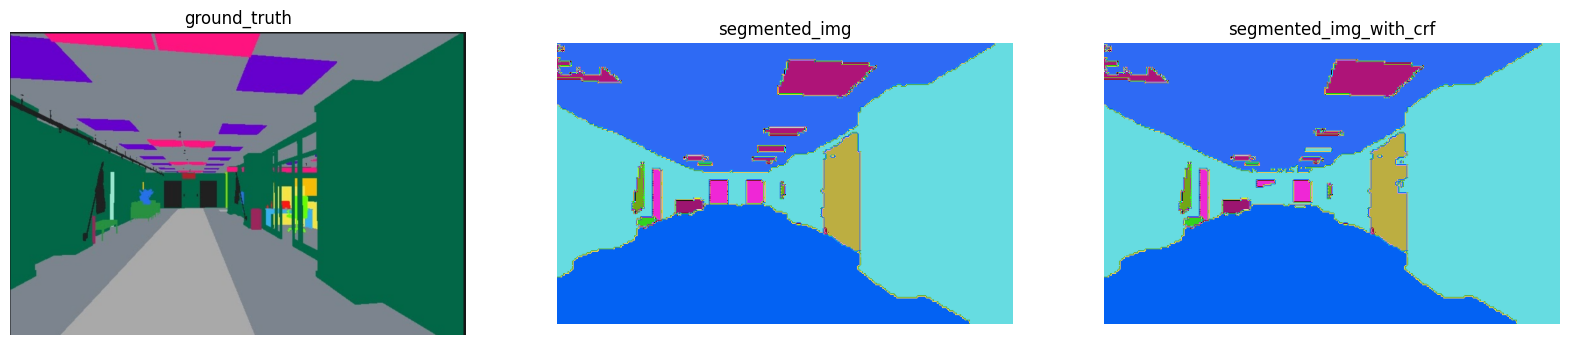

In [ ]:
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

np.random.seed(42)
PALETTE = np.random.randint(0, 255, (256, 3), dtype=np.uint8)

def colorize_mask(mask):
  mask = cv2.resize(mask, (520, 320))
  return PALETTE[mask]

img = cv2.imread("sample_rgb_image.png")

print("Original image: ")
cv2_imshow(img)

# Load images
img1 = mpimg.imread('expected_ground_truth.png')

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(img1)
ax[0].axis('off')  # Hide axes for a cleaner look
ax[0].set_title('ground_truth')

ax[1].imshow(colorize_mask(segmented_img))
ax[1].axis('off')
ax[1].set_title('segmented_img')

ax[2].imshow(colorize_mask(segmented_img_with_crf))
ax[2].axis('off')
ax[2].set_title('segmented_img_with_crf')

plt.show()

# Label inspection

In [ ]:
def inspect_segmentation(seg_path):
    try:
      print(seg_path)
      seg = np.array(Image.open(seg_path))
      print(f"Shape:        {seg.shape}")
      print(f"dtype:        {seg.dtype}")
      print(f"Min/Max:      {seg.min()} / {seg.max()}")
      print(f"Unique vals:  {np.unique(seg)[:20]} ...")
      print()
      if seg.ndim == 3:
          print("This is an RGB image (3 channels) NOT suitable as label map.")
          print("   Use tesse_seg_cam_converted_image_raw instead.")
      elif seg.max() > 149:
          print(f"Labels exceed 149 needs remapping, max = {seg.max()}")
      else:
          print("valid single-channel label map (0–149).")
    except:
      print(f"No image found at: {seg_path}")


drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"


# print("tesse_seg_cam_rgb_image_raw (probably wrong) ")
# sample_rgb_seg = next(Path(f"{drive_path}/tesse_seg_cam_rgb_image_raw").glob("*"))
# inspect_segmentation(sample_rgb_seg)

print("tesse_seg_cam_converted_image_raw (probably correct)")
sample_converted = next(Path(f"{drive_path}/tesse_seg_cam_converted_image_raw").glob("*.[!csv]*"))
inspect_segmentation(sample_converted)

tesse_seg_cam_converted_image_raw (probably correct)
/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_seg_cam_converted_image_raw/462204900000.jpg
Shape:        (480, 720)
dtype:        uint8
Min/Max:      2 / 210
Unique vals:  [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22] ...

Labels exceed 149 needs remapping, max = 210


In [ ]:
import json, requests
config_url = "https://huggingface.co/shi-labs/oneformer_ade20k_swin_large/raw/main/preprocessor_config.json"
cfg = json.loads(requests.get(config_url).text)
print("num_text:", cfg.get("num_text"))
print("task_seq_len:", cfg.get("task_seq_len"))

num_text: None
task_seq_len: None


In [ ]:

import numpy as np
seg = np.array(Image.open("GT_11554880000.jpg"))
print(f"Shape:        {seg.shape}")
print(f"dtype:        {seg.dtype}")
print(f"Min/Max:      {seg.min()} / {seg.max()}")
print(f"Unique vals:  {np.unique(seg)[:20]} ...")
print(480*720)
unknown_labels = []
larger_labels = seg[seg>218 and seg<0]
unique_labels = np.unique(seg)
print(len(unique_labels))
print(len(larger_labels))


Shape:        (480, 720)
dtype:        uint8
Min/Max:      5 / 211
Unique vals:  [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 24 25 26] ...
345600


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# OneFormer - Level2

In [ ]:
import os
import pandas as pd
drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"
rgb_dir = drive_path + "/tesse_left_cam_rgb_image_raw"
seg_dir = drive_path + "/tesse_seg_cam_converted_image_raw"
print(f"Files in {rgb_dir}:")
if os.path.exists(rgb_dir):
    rgb_files = os.listdir(rgb_dir)
    df = pd.DataFrame({'rgb':rgb_files})
else:
    print(f"Directory not found: {rgb_dir}")

print(f"\nFiles in {seg_dir}:")
if os.path.exists(seg_dir):
    seg_files = os.listdir(seg_dir)
    df['seg'] = seg_files
else:
    print(f"Directory not found: {seg_dir}")

missing_set = (set(df['rgb']) - set(df['seg'])).union(set(df['seg']) - set(df['rgb']))
print(missing_set)
missing_values = df[~df['rgb'].isin(df['seg'])]['rgb']
print(missing_values)

Files in /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_left_cam_rgb_image_raw:

Files in /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_seg_cam_converted_image_raw:
set()
Series([], Name: rgb, dtype: object)


In [ ]:

!pip install transformers torch torchvision

from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import numpy as np
import torch
from pathlib import Path


processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
)
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large"
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

The image processor of type `OneFormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ade20k_panoptic.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/880M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/879M [00:00<?, ?B/s]

OneFormerForUniversalSegmentation(
  (model): OneFormerModel(
    (pixel_level_module): OneFormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=192, out_features=192, bias=True)
                      (key): Linear(in_features=192, out_features=192, bias=True)
                      (value): Li

## failed training on uhumans GTlabels:

```
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import torch
import numpy as np

class UHumans2Dataset(Dataset):
    def __init__(self, rgb_dir, seg_dir, processor):
        self.rgb_files = sorted(Path(rgb_dir).glob("*.jpg"))
        self.seg_dir = Path(seg_dir)
        self.processor = processor

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        # seg_path = self.seg_dir / (rgb_path.stem + ".png")
        seg_path = self.seg_dir / (rgb_path.stem + ".jpg")

        image = Image.open(rgb_path).convert("RGB")
        seg = Image.open(seg_path)

        inputs = self.processor(
            images=image,
            segmentation_maps=seg,
            task_inputs=["semantic"],
            return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in inputs.items()}

drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"
dataset = UHumans2Dataset(
    rgb_dir=drive_path+"/tesse_left_cam_rgb_image_raw",
    seg_dir=drive_path+"/tesse_seg_cam_converted_image_raw",
    processor=processor
)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
model.train()

for epoch in range(5):
    for batch in loader:
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1} loss: {loss.item():.4f}")

model.save_pretrained("./oneformer_uhumans2_finetuned")
processor.save_pretrained("./oneformer_uhumans2_finetuned")
```

part - 2:

```
# ── Dataset ──────────────────────────────────────────────────────────────────
class UHumans2Dataset(Dataset):
    def __init__(self, rgb_dir, seg_dir, processor):
        self.rgb_files = sorted(Path(rgb_dir).glob("*.jpg"))
        self.seg_dir = Path(seg_dir)
        self.processor = processor

        # Verify matching files exist
        missing = []
        for f in self.rgb_files:
            seg_candidate = self._find_seg(f)
            if seg_candidate is None:
                missing.append(f.name)
        if missing:
            print(f"{len(missing)} RGB files have no matching seg file. First 5: {missing[:5]}")

    def _find_seg(self, rgb_path):
        for ext in [".png", ".jpg"]:
            p = self.seg_dir / (rgb_path.stem + ext)
            if p.exists():
                return p
        return None

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        seg_path = self._find_seg(rgb_path)

        if seg_path is None:
            raise FileNotFoundError(f"No seg file for {rgb_path.name}")

        image = Image.open(rgb_path).convert("RGB")
        seg = Image.open(seg_path)

        seg_array = np.array(seg)
        if seg_array.ndim == 3:
            # RGB segmentation image — take only the R channel
            # (uHumans2 encodes label ID in R channel of the converted image)
            seg = Image.fromarray(seg_array[:, :, 0])

        inputs = self.processor(
            images=image,
            segmentation_maps=seg,
            task_inputs=["semantic"],
            return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in inputs.items()}


drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"
dataset = UHumans2Dataset(
    rgb_dir=f"{drive_path}/tesse_left_cam_rgb_image_raw",
    seg_dir=f"{drive_path}/tesse_seg_cam_converted_image_raw",
    processor=processor
)

print(f"Dataset size: {len(dataset)}")

sample = dataset[0]
print("Sample keys:", list(sample.keys()))
print("pixel_values shape:", sample["pixel_values"].shape)

loader = DataLoader(dataset, batch_size=1, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
model = model.to(device)
model.train()

for epoch in range(5):
    epoch_loss = 0.0
    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
        if i % 20 == 0:
            print(f"  Epoch {epoch+1} step {i} loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} avg loss: {epoch_loss/len(loader):.4f}")

model.save_pretrained("./oneformer_uhumans2_finetuned")
processor.save_pretrained("./oneformer_uhumans2_finetuned")
print("Saved fine-tuned model.")
```

In [ ]:
# !pip install transformers torch torchvision

from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
from pathlib import Path

processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
    num_text=134,
    task_seq_len=77,
)
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large"
)



Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

# Train oneformer on uhumans2_office

In [ ]:
!pip install transformers torch torchvision

import os
import pandas as pd
drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"

from transformers import (
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
    OneFormerConfig
)
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
from pathlib import Path

# ── Build the remap lookup table from uhumans2_office.yaml ───────────────────
# sub_id = raw simulator label, super_id = uHumans2 office label
REMAP = {
    10: 1,   # air_vent
    5:  2,   # books
    14: 3,   # floor
    202: 0,  # unknown
    128: 4,  # ceiling_light
    191: 19, # wall
    100: 9,  # cabinet
    28: 5,   # chair
    36: 7,   # couch
    163: 16, # desk
    151: 10, # computer
    71: 3,   # floor
    86: 11,  # lamp
    93: 6,   # bench
    198: 12, # painting
    130: 13, # plant
    131: 14, # sign
    148: 20, # human
    161: 17, # cubicle
    193: 18, # trashcan
    203: 15, # stairs
    204: 0,  # unknown
}
NUM_CLASSES = 21  # uHumans2 office labelspace

# Build a fast numpy lookup array (index = raw ID, value = remapped ID)
# Any raw ID not in the remap table gets mapped to 0 (unknown)
REMAP_LUT = np.zeros(256, dtype=np.uint8)
for raw_id, remapped_id in REMAP.items():
    if raw_id < 256:
        REMAP_LUT[raw_id] = remapped_id

def apply_remap(seg_array: np.ndarray) -> np.ndarray:
    """Convert raw simulator label IDs to uHumans2 office label IDs."""
    # Clip to 255 to stay within LUT bounds
    clipped = np.clip(seg_array, 0, 255).astype(np.uint8)
    return REMAP_LUT[clipped]

# ── Verify remap on one sample ────────────────────────────────────────────────
drive_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset"
sample_seg = next(Path(f"{drive_path}/tesse_seg_cam_converted_image_raw").glob("*.jpg"))
raw = np.array(Image.open(sample_seg))
remapped = apply_remap(raw)

print(f"Raw labels:      {sorted(np.unique(raw).tolist())}")
print(f"Remapped labels: {sorted(np.unique(remapped).tolist())}")
print(f"All remapped IDs within 0-20: {remapped.max() <= 20}")

# ── Load model config to get correct num_text ─────────────────────────────────
model_config = OneFormerConfig.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
print(f"\nnum_text from config: {model_config.num_text}")
print(f"task_seq_len: {model_config.task_seq_len}")

# Patch processor with correct values
processor = OneFormerProcessor.from_pretrained("shi-labs/oneformer_ade20k_swin_large")
processor.image_processor.num_text = model_config.num_text
processor.image_processor.task_seq_len = model_config.task_seq_len

# ── Reinitialize model head for 21 classes ────────────────────────────────────
# The pretrained model has 150-class output — we replace the head for 21 classes
# but keep all the backbone weights (transfer learning)
model_config.num_labels = NUM_CLASSES

# Build class metadata for the 21 uHumans2 labels
UHUMANS2_CLASSES = [
    "unknown", "air_vent", "books", "floor", "ceiling_light",
    "chair", "bench", "couch", "stairs", "cabinet",
    "computer", "lamp", "painting", "plant", "sign",
    "stairs", "desk", "cubicle", "trashcan", "wall", "human"
]
model_config.id2label = {i: name for i, name in enumerate(UHUMANS2_CLASSES)}
model_config.label2id = {name: i for i, name in enumerate(UHUMANS2_CLASSES)}

# Load pretrained weights then replace the classification head
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
    config=model_config,
    ignore_mismatched_sizes=True  # allows head replacement
)

# ── Dataset ───────────────────────────────────────────────────────────────────
class UHumans2Dataset(Dataset):
    def __init__(self, rgb_dir, seg_dir, processor):
        self.rgb_files = sorted(Path(rgb_dir).glob("*.jpg"))
        self.seg_dir = Path(seg_dir)
        self.processor = processor

        # Check for missing pairs
        missing = [f.name for f in self.rgb_files if not self._find_seg(f)]
        if missing:
            print(f"⚠️  {len(missing)} files missing seg pair. First 3: {missing[:3]}")
        print(f"Dataset: {len(self.rgb_files)} samples")

    def _find_seg(self, rgb_path):
        for ext in [".jpg", ".png"]:
            p = self.seg_dir / (rgb_path.stem + ext)
            if p.exists():
                return p
        return None

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        seg_path = self._find_seg(rgb_path)
        if seg_path is None:
            raise FileNotFoundError(f"No seg for {rgb_path.name}")

        image = Image.open(rgb_path).convert("RGB")

        # Load and remap labels
        raw_seg = np.array(Image.open(seg_path))
        if raw_seg.ndim == 3:
            raw_seg = raw_seg[:, :, 0]
        remapped_seg = apply_remap(raw_seg)
        seg = Image.fromarray(remapped_seg)

        inputs = self.processor(
            images=image,
            segmentation_maps=seg,
            task_inputs=["semantic"],
            return_tensors="pt"
        )
        return {k: v.squeeze(0) for k, v in inputs.items()}

# ── Training ──────────────────────────────────────────────────────────────────
dataset = UHumans2Dataset(
    rgb_dir=f"{drive_path}/tesse_left_cam_rgb_image_raw",
    seg_dir=f"{drive_path}/tesse_seg_cam_converted_image_raw",
    processor=processor
)

# Test one sample before training
print("\nTesting single sample...")
sample = dataset[0]
print("Keys:", list(sample.keys()))
print("pixel_values shape:", sample["pixel_values"].shape)
print("Single sample OK ✓")

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTraining on: {device}")
model = model.to(device)

# Use a lower LR for backbone, higher for the new head
optimizer = torch.optim.AdamW([
    {"params": model.model.parameters(), "lr": 1e-5},   # pretrained backbone
    {"params": model.class_predictor.parameters(), "lr": 1e-4},  # new head
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=5 * len(loader)
)

best_loss = float("inf")
model.train()

for epoch in range(5):
    epoch_loss = 0.0
    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
        if i % 20 == 0:
            print(f"  Epoch {epoch+1} [{i}/{len(loader)}] loss: {loss.item():.4f}")

    avg = epoch_loss / len(loader)
    print(f"Epoch {epoch+1} avg loss: {avg:.4f}")

    if avg < best_loss:
        best_loss = avg
        model.save_pretrained("./oneformer_uhumans2_best")
        processor.save_pretrained("./oneformer_uhumans2_best")
        print(f"  ✓ Saved best model (loss={avg:.4f})")

model.save_pretrained("./oneformer_uhumans2_finetuned")
processor.save_pretrained("./oneformer_uhumans2_finetuned")
print("Training complete.")

# OneFormer on lab_Dataset

In [ ]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/labwalk/"

topic_name = "D435_color_image_raw"



## Load Model

In [ ]:

!pip install transformers torch torchvision

from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import numpy as np
import torch
from pathlib import Path


processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large",
)
model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_large"
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

The image processor of type `OneFormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ade20k_panoptic.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/880M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/879M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

OneFormerForUniversalSegmentation(
  (model): OneFormerModel(
    (pixel_level_module): OneFormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=192, out_features=192, bias=True)
                      (key): Linear(in_features=192, out_features=192, bias=True)
                      (value): Li

## Segment function

In [ ]:

def segment_image(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    # OneFormer needs a task input
    inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    seg = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0]
    return seg.numpy().astype(np.uint8)

## Visualize results

In [ ]:
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

np.random.seed(42)
PALETTE = np.random.randint(0, 255, (256, 3), dtype=np.uint8)

def colorize_mask(mask):
  mask = cv2.resize(mask, (520, 320))
  return PALETTE[mask]

def viz_results(image_path, segmented_img):
  img = cv2.imread(image_path)

  # Create a figure with 1 row and 2 columns
  fig, ax = plt.subplots(1, 2, figsize=(20, 10))

  ax[0].imshow(img)
  ax[0].axis('off')  # Hide axes for a cleaner look
  ax[0].set_title('Original_image')

  ax[1].imshow(segmented_img)
  ax[1].axis('off')
  ax[1].set_title('segmented_img')

  plt.show()

loading 10 images from /content/drive/MyDrive/SBU/Advanced_Project_Robotics/bag_pcd_topics/D435_color_image_raw


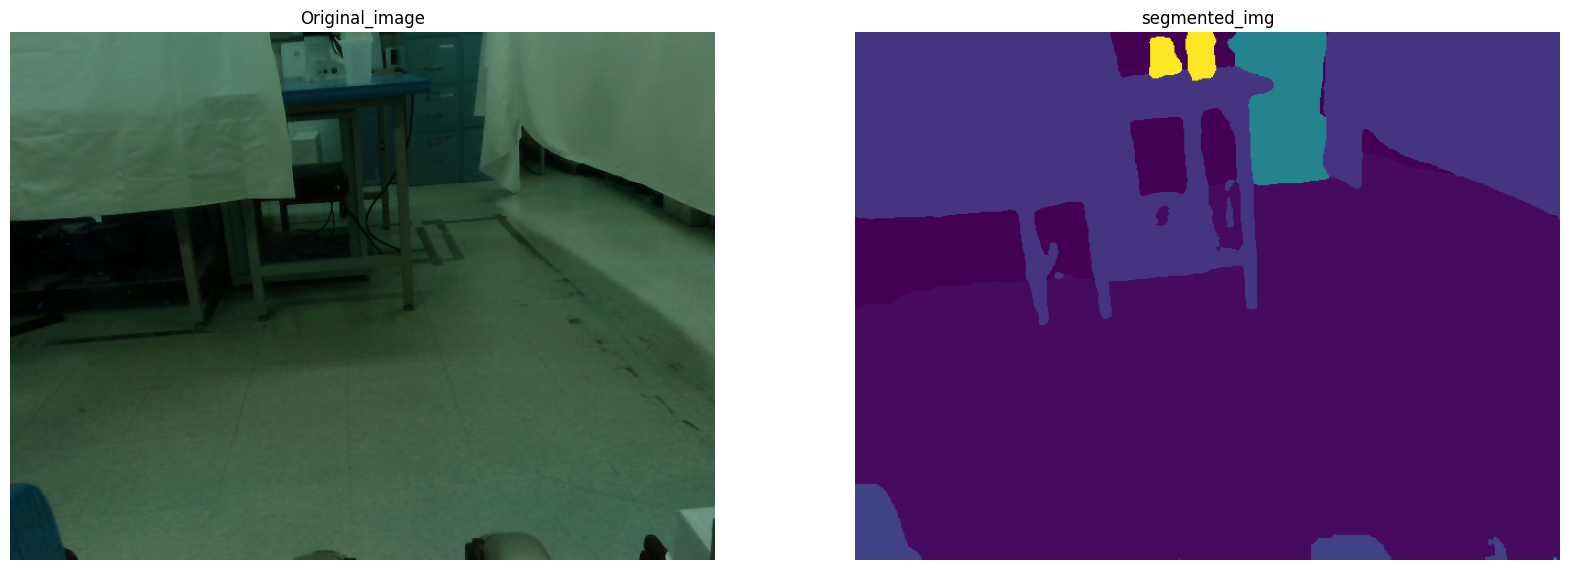

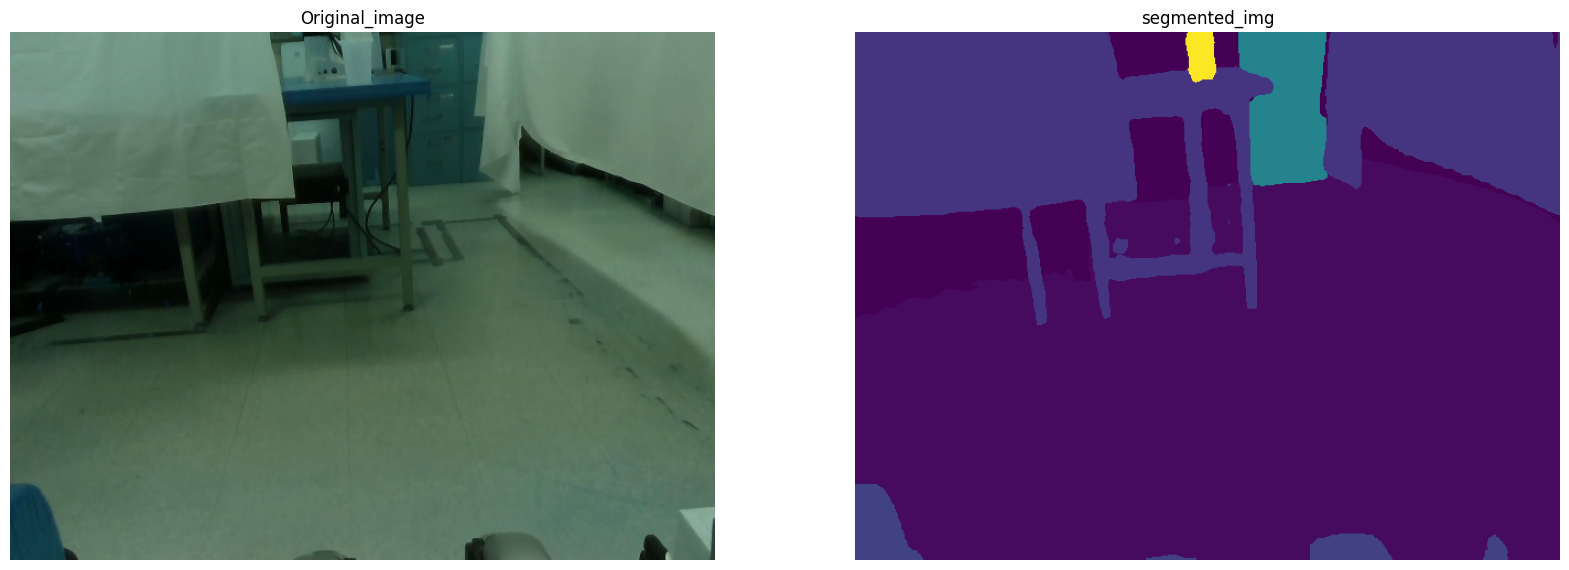

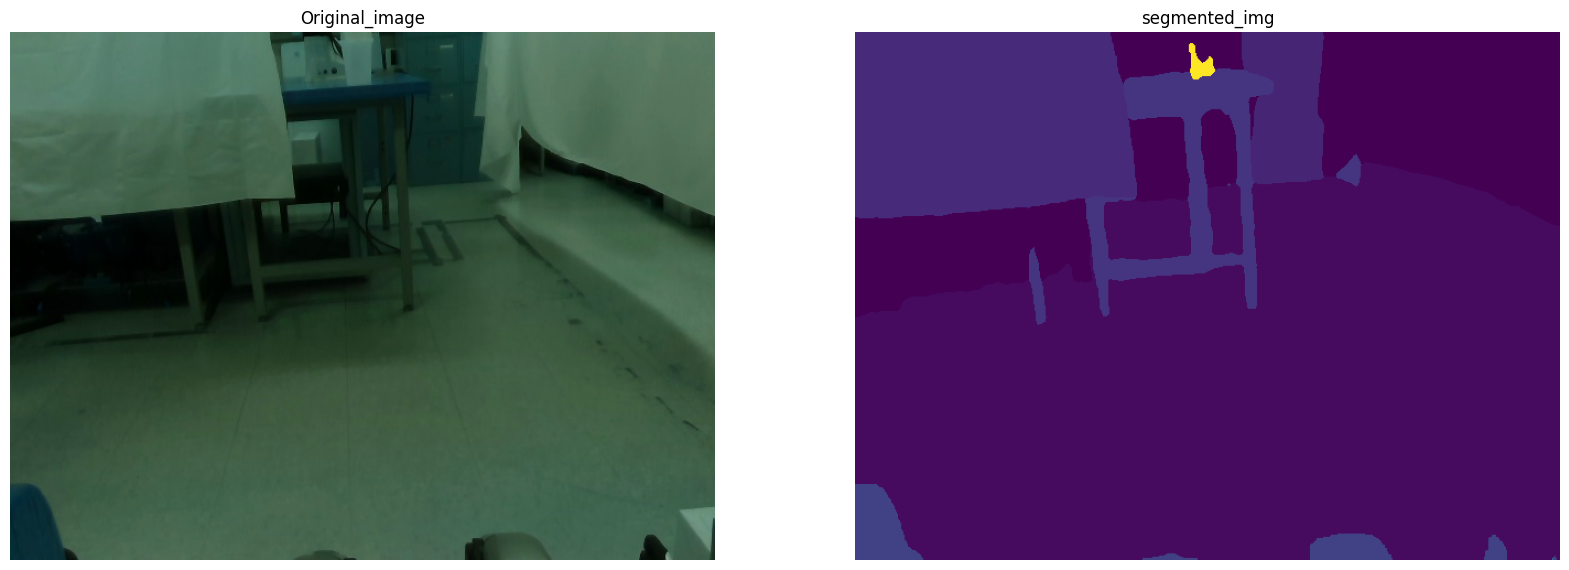

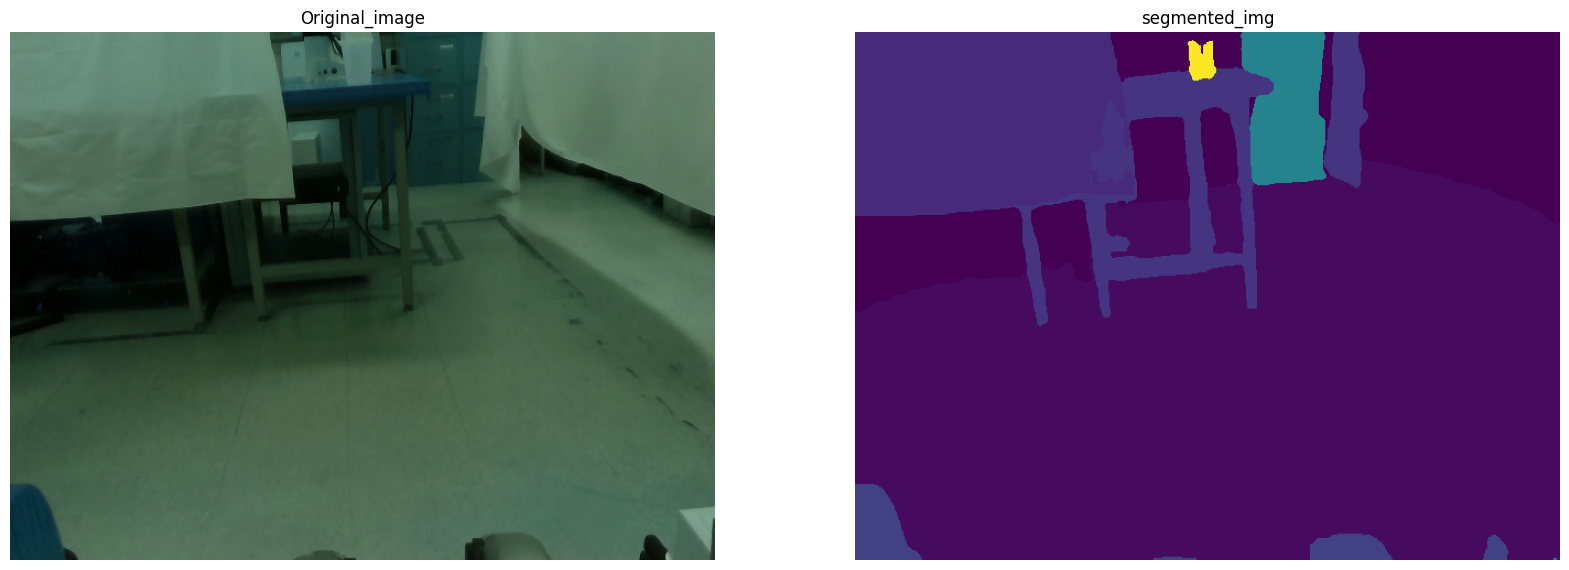

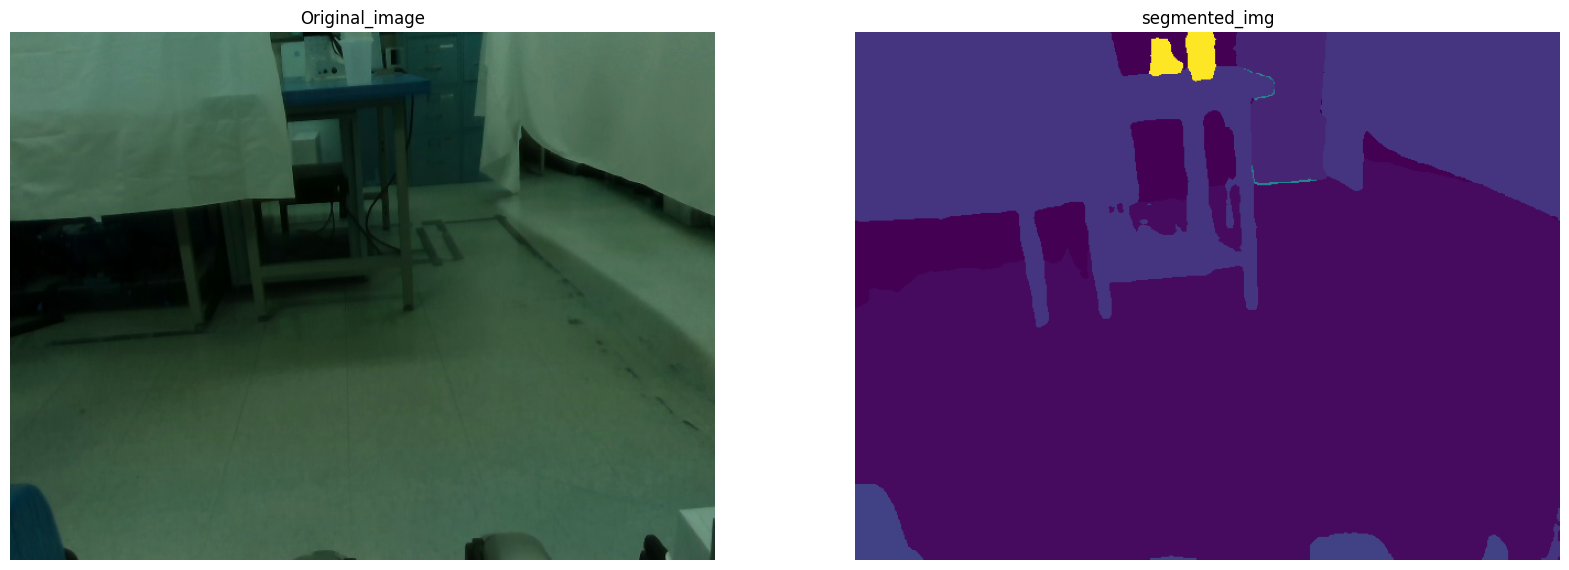

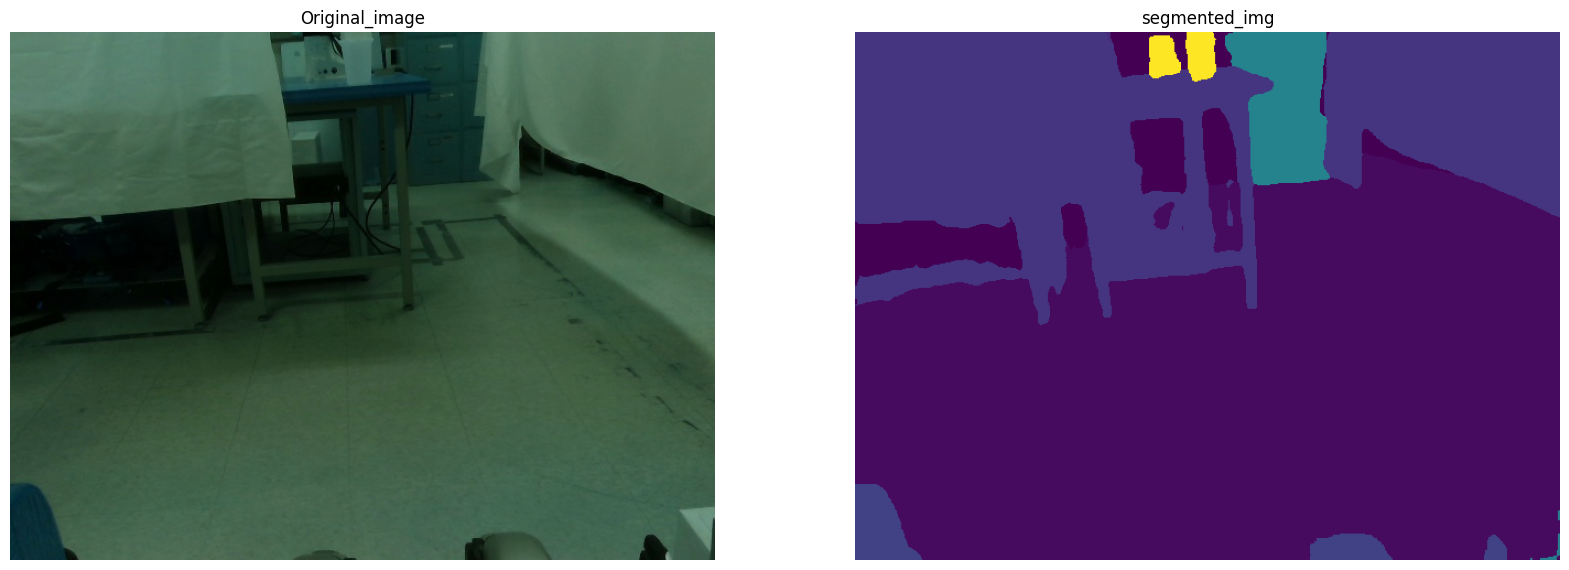

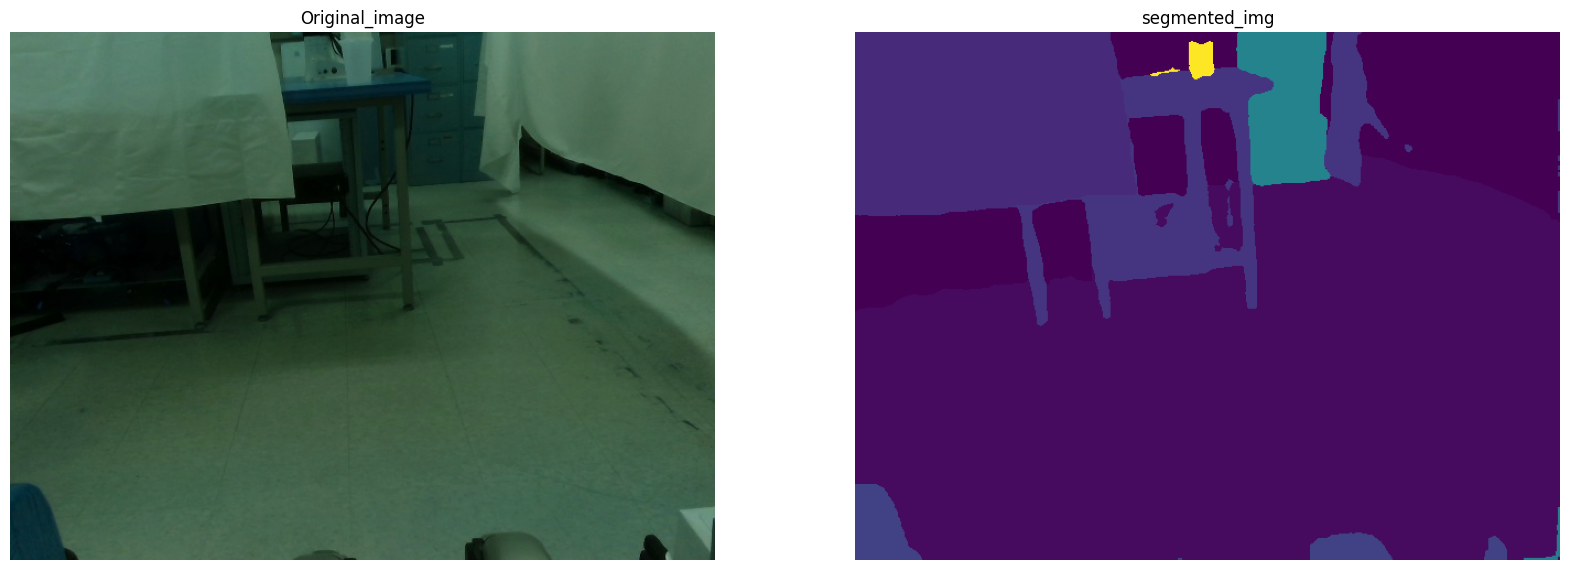

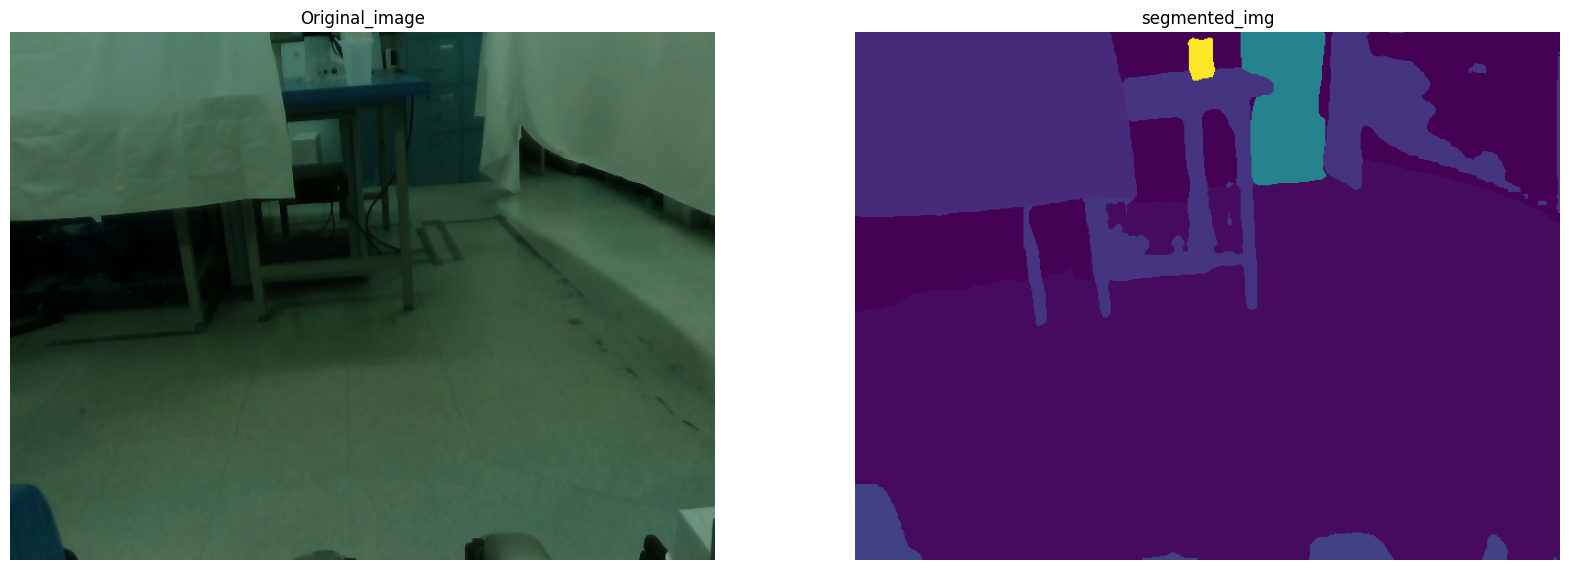

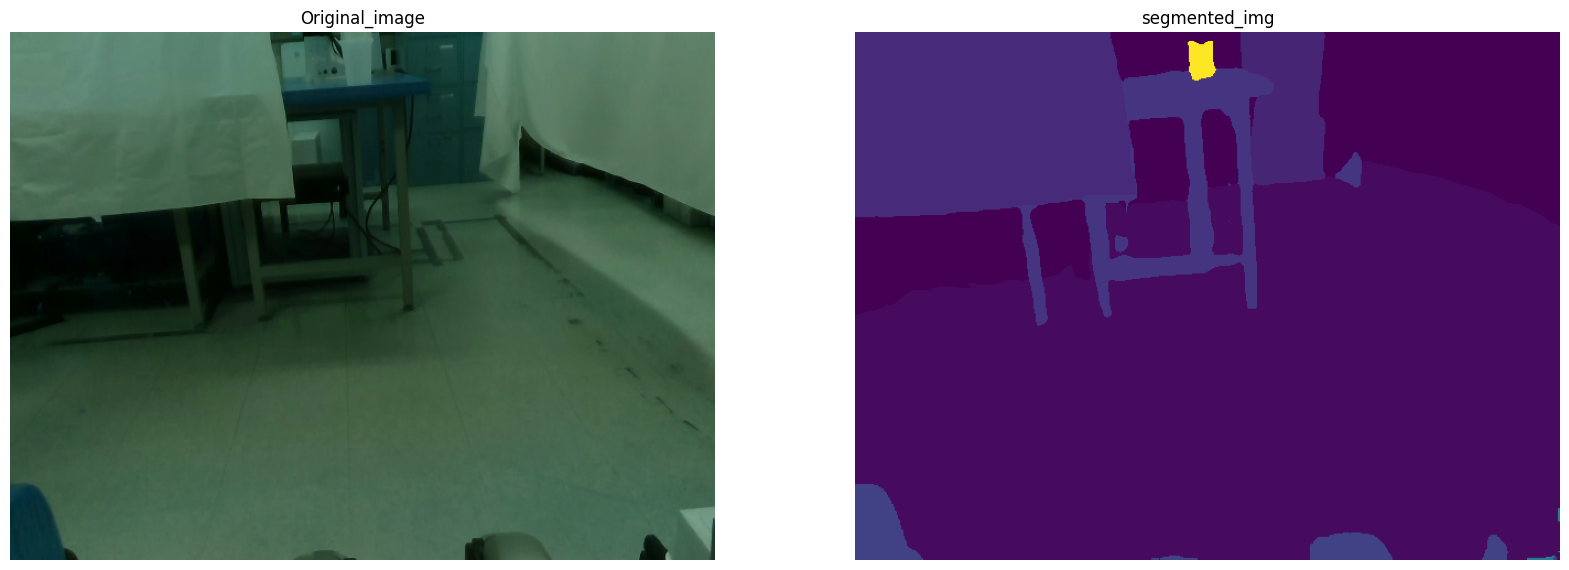

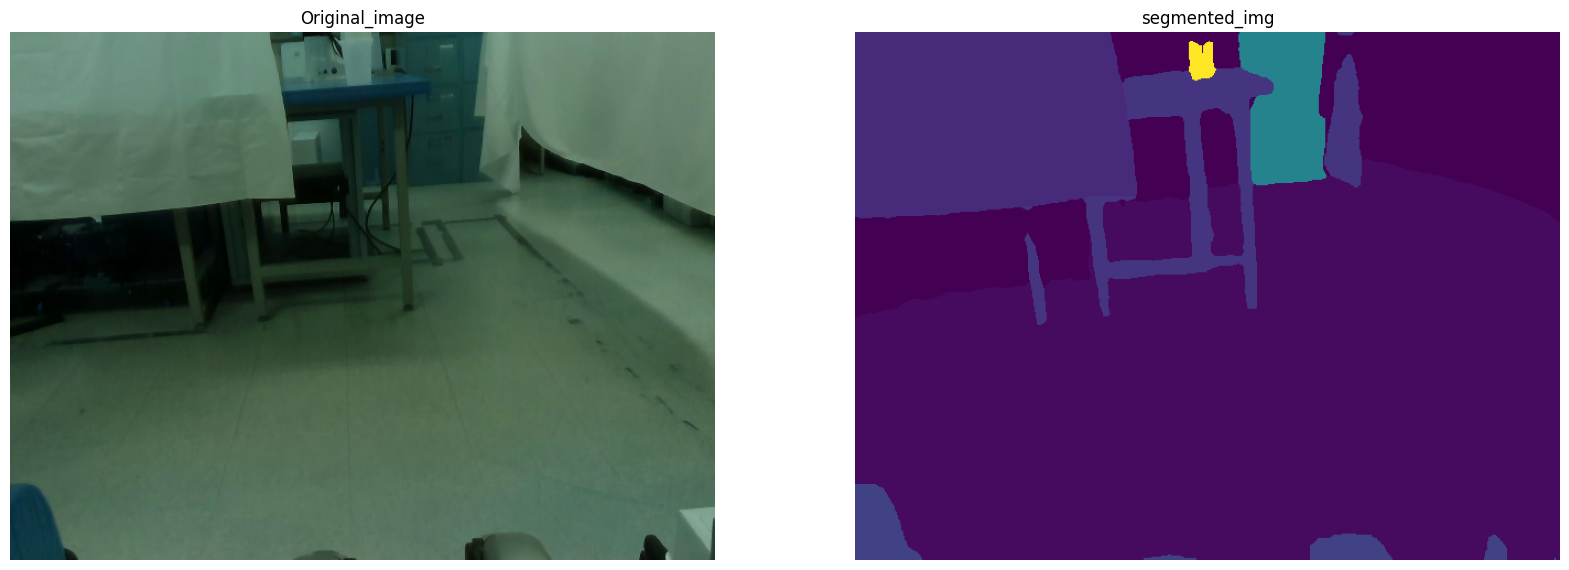

In [ ]:
raw_img_path = Path(dataset_path+"/"+topic_name)

raw_img_files = [f for f in raw_img_path.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]

print(f"loading {10} images from {raw_img_path}")

for img_file in raw_img_files[:10]:
  seg_img = segment_image(image_path=img_file)
  viz_results(img_file, seg_img)

# Segment all images

In [ ]:
import torch
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import numpy as np
from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation

# 1. Configuration & Paths
input_path = Path(dataset_path+"D435_color_image_raw")
output_path = Path(dataset_path+"D435_seg_cam_rgb_image_raw")
output_path.mkdir(parents=True, exist_ok=True)

# 2. Initialize Model & Processor
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = processor
model = model.to(device)
model.eval()

# 3. Inference Loop
image_files = [f for f in input_path.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
print(f"Processing {len(image_files)} images on {device}...")

for img_file in tqdm(image_files):
    # Load image
    image = Image.open(img_file).convert("RGB")

    # Pre-process (OneFormer requires a 'task_inputs' list)
    inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt").to(device)

    # Forward Pass
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process to Semantic Segmentation
    # target_sizes expects (height, width)
    predicted_map = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0]

    # Save Result
    seg_array = predicted_map.cpu().numpy().astype(np.uint8)
    res_image = Image.fromarray(seg_array)
    res_image.save(output_path / f"{img_file.stem}_prediction.png")

print(f"Done! Results are in: {output_path}")

Processing 3030 images on cuda...


100%|██████████| 3030/3030 [44:42<00:00,  1.13it/s]

Done! Results are in: /content/drive/MyDrive/SBU/Advanced_Project_Robotics/labwalk/D435_seg_cam_rgb_image_raw


In [ ]:
from pathlib import Path

img_file = Path("sample_rgb_image.png")
print(img_file.name.replace("_image.png", ""))  # Output: sample_rgb

TypeError: Path.replace() takes 2 positional arguments but 3 were given